# Credit Card Fraud Detection

## Objective

Predict whether a transaction is fraudulent based on various features of the transaction. This is a binary classification problem where the target variable is Fraud, indicating whether a transaction is fraudulent(1) or legitimate (0).

## Building a model using Logistic Regression Algorithm

In [3]:
# Import necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
# Load the dataset from a CSV file
df = pd.read_csv("credit_card_fraud_dataset_realistic.csv")

# Display the first few rows of the dataset
df.head()

,TransactionID,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount,Fraud
0,1,3198.94,2.76,Retail,52,Female,94901,Rural,1,0
1,2,129.93,172.97,Online,20,Male,81471,Urban,5,1
2,3,1378.77,163.61,Online,71,Male,91228,Suburban,3,1
3,4,1119.94,128.87,Travel,41,Female,108040,Rural,3,1
4,5,3683.67,64.04,Travel,55,Male,103809,Suburban,4,1


## Essential Exploratory Data Analysis (EDA)

In [5]:
# Summary statistics

df.describe()

,TransactionID,TransactionAmount,TransactionTime,CustomerAge,CustomerIncome,PreviousFraudCount,Fraud
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,2400.449000,117.330200,52.100000,105764.280000,2.500000,0.660000
std,29.011492,1473.544873,70.352407,19.518186,50643.314362,1.690735,0.476095
min,1.000000,37.460000,0.140000,19.000000,21545.000000,0.000000,0.000000
25%,25.750000,1137.497500,55.160000,34.500000,62462.750000,1.000000,0.000000
50%,50.500000,2413.110000,112.765000,53.000000,108077.000000,2.000000,1.000000
75%,75.250000,3555.002500,182.655000,70.250000,142714.250000,4.000000,1.000000
max,100.000000,4987.700000,239.830000,80.000000,198032.000000,5.000000,1.000000


In [6]:
# Check for missing values

df.isnull().sum()

TransactionID          0
TransactionAmount      0
TransactionTime        0
MerchantCategory       0
CustomerAge            0
CustomerGender         0
CustomerIncome         0
TransactionLocation    0
PreviousFraudCount     0
Fraud                  0
dtype: int64

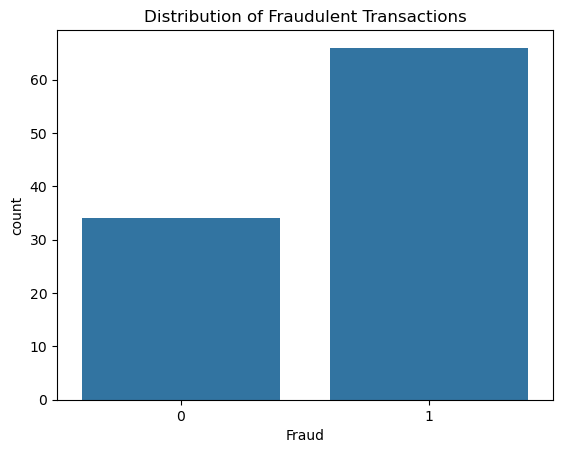

In [7]:
# Distibution of target variable 

sns.countplot(x="Fraud", data=df)
plt.title("Distribution of Fraudulent Transactions")
plt.show()

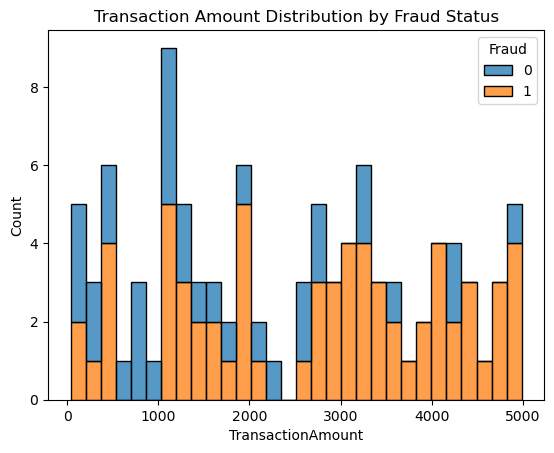

In [8]:
# Distribution of Transaction Amount by Fraud status

sns.histplot(data=df, x="TransactionAmount", hue="Fraud", multiple="stack", bins=30)
plt.title("Transaction Amount Distribution by Fraud Status")
plt.show()

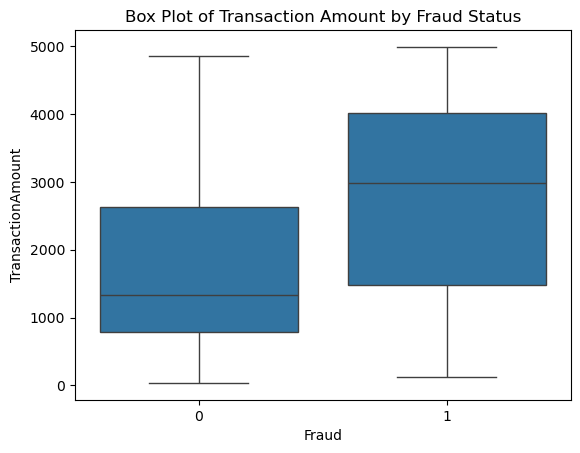

In [9]:
# Box plot for Transaction Amount by Fraud status

sns.boxplot(x="Fraud", y="TransactionAmount", data=df)
plt.title("Box Plot of Transaction Amount by Fraud Status")
plt.show()

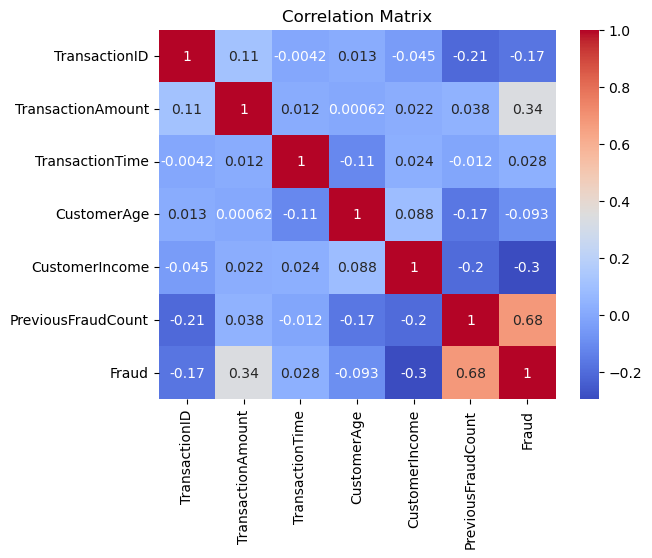

In [10]:
# Correlation matrix

num_cols = list()

for column in df.columns:
    if df[column].dtype != object:
        num_cols.append(column)

correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Data Preprocessing

In [11]:
# Encoding Categorical Variables
label_encoders = {} #--> Here we are taking a dictionary in which we store the data 
#---> we use "kavek_encoders" because these are non-numerical data to convert the non-numeric data to numeric data
for column in ["MerchantCategory", "CustomerGender", "TransactionLocation"]:
    le = LabelEncoder() #--> Assigning to a variable
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  #---> Sending data to the dictianary


# Features and target
X = df.drop(["TransactionID", "Fraud"], axis=1)  #--->Why we are droppping because in transactionID all values are unique and Fraud because it is the output coulumn which we are using in "y" and axis=1  performing operration by column is gonna delete the whole column
y = df["Fraud"]
    

In [12]:
X.head()

,TransactionAmount,TransactionTime,MerchantCategory,CustomerAge,CustomerGender,CustomerIncome,TransactionLocation,PreviousFraudCount
0,3198.94,2.76,2,52,0,94901,0,1
1,129.93,172.97,0,20,1,81471,2,5
2,1378.77,163.61,0,71,1,91228,1,3
3,1119.94,128.87,3,41,0,108040,0,3
4,3683.67,64.04,3,55,1,103809,1,4


In [13]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [14]:
# Feature scaling
# Going to scale the values becoz in the table the records have big difference which affect in scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
# All the things we do above --> our dataset is ready to apply for Logistic Regression
# Logistic Regression

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)

In [16]:
# Display accuracy and performance metrices

print(f"Logistic Regression Accuracy: {logreg_accuracy*100:.2f}")
print("\nLogistic Regression Classificaton Report:")
print(classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 93.33

Logistic Regression Classificaton Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.96      0.96      0.96        24

    accuracy                           0.93        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.93      0.93      0.93        30



# Building A Model Using KNN Algorithm

In [17]:
from sklearn.neighbors import KNeighborsClassifier 
#---> Sub-Module is= "neighbors" and inside it has a class called "KNeighborsClassifier"

In [18]:
#--> If want to get information about the KNeighborsClassifier class then:-
help(KNeighborsClassifier)

Help on class KNeighborsClassifier in module sklearn.neighbors._classification:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(
 |      n_neighbors=5,
 |      *,
 |      weights='uniform',
 |      algorithm='auto',
 |      leaf_size=30,
 |      p=2,
 |      metric='minkowski',
 |      metric_params=None,
 |      n_jobs=None
 |  )
 |
 |  Classifier implementing the k-nearest neighbors vote.
 |
 |  Read more in the :ref:`User Guide <classification>`.
 |
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by 

In [19]:
# K-Nearest Neighbors
#--> Knn is a Label/variable assigning
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

In [20]:
# Display accuracy and performance metrics
print(f"K-Nearest Neighbors Accuracy: {knn_accuracy*100:.2f}")
print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, knn_pred))

K-Nearest Neighbors Accuracy: 80.00

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.83      0.62         6
           1       0.95      0.79      0.86        24

    accuracy                           0.80        30
   macro avg       0.72      0.81      0.74        30
weighted avg       0.86      0.80      0.82        30



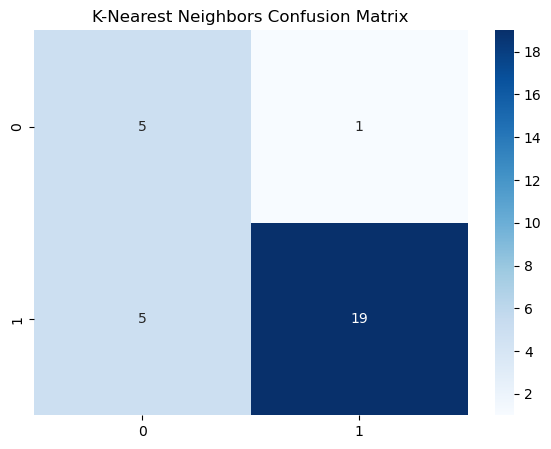

In [21]:
# Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, knn_pred), annot=True, fmt="d", cmap="Blues")
plt.title("K-Nearest Neighbors Confusion Matrix")
plt.show()

# Building a model using Decision Tree Algorithm

In [22]:
from sklearn.tree import DecisionTreeClassifier
#--> tree = module
#--> DecisionTreeClassifier = class  

In [23]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(
 |      *,
 |      criterion='gini',
 |      splitter='best',
 |      max_depth=None,
 |      min_samples_split=2,
 |      min_samples_leaf=1,
 |      min_weight_fraction_leaf=0.0,
 |      max_features=None,
 |      random_state=None,
 |      max_leaf_nodes=None,
 |      min_impurity_decrease=0.0,
 |      class_weight=None,
 |      ccp_alpha=0.0,
 |      monotonic_cst=None
 |  )
 |
 |  A decision tree classifier.
 |
 |  Read more in the :ref:`User Guide <tree>`.
 |
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |
 |  splitter : {"best",

In [24]:
# Decision Tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

In [25]:
# Display accuracy and performance metrics

print(f"Decision Tree Accuracy: {decision_tree_accuracy*100:.2f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, decision_tree_pred))

Decision Tree Accuracy: 93.33

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       1.00      0.92      0.96        24

    accuracy                           0.93        30
   macro avg       0.88      0.96      0.91        30
weighted avg       0.95      0.93      0.94        30



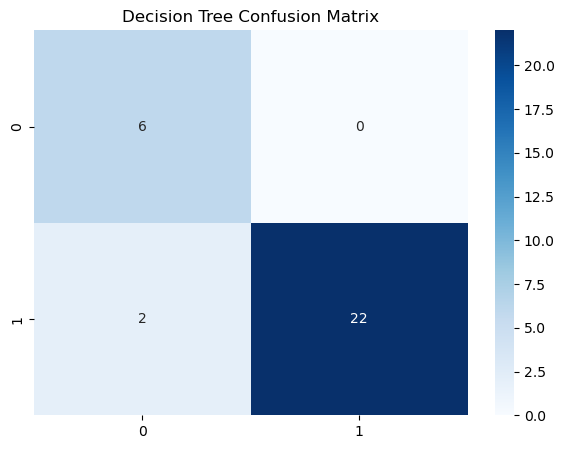

In [26]:
# Confusion Matrix

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, decision_tree_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Building a model using Support Vectore Machine Algorithm

In [28]:
from sklearn.svm import SVC
#---> "svm" is a sub-module inside sklearn and inside "svm" it has classes and functions "SVM"

# Support Vector Machine

svm = SVC()
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

In [29]:
help(SVC)

Help on class SVC in module sklearn.svm._classes:

class SVC(sklearn.svm._base.BaseSVC)
 |  SVC(
 |      *,
 |      C=1.0,
 |      kernel='rbf',
 |      degree=3,
 |      gamma='scale',
 |      coef0=0.0,
 |      shrinking=True,
 |      probability=False,
 |      tol=0.001,
 |      cache_size=200,
 |      class_weight=None,
 |      verbose=False,
 |      max_iter=-1,
 |      decision_function_shape='ovr',
 |      break_ties=False,
 |      random_state=None
 |  )
 |
 |  C-Support Vector Classification.
 |
 |  The implementation is based on libsvm. The fit time scales at least
 |  quadratically with the number of samples and may be impractical
 |  beyond tens of thousands of samples. For large datasets
 |  consider using :class:`~sklearn.svm.LinearSVC` or
 |  :class:`~sklearn.linear_model.SGDClassifier` instead, possibly after a
 |  :class:`~sklearn.kernel_approximation.Nystroem` transformer or
 |  other :ref:`kernel_approximation`.
 |
 |  The multiclass support is handled according to a

In [30]:
# Display accuracy and performance metrics

print(f"Supprt Vector Machine Accuracy:{svm_accuracy*100:.2f}")
print("\nSupport Vector Machine Classification Report:")
print(classification_report(y_test, svm_pred))

Supprt Vector Machine Accuracy:96.67

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.96      1.00      0.98        24

    accuracy                           0.97        30
   macro avg       0.98      0.92      0.94        30
weighted avg       0.97      0.97      0.97        30



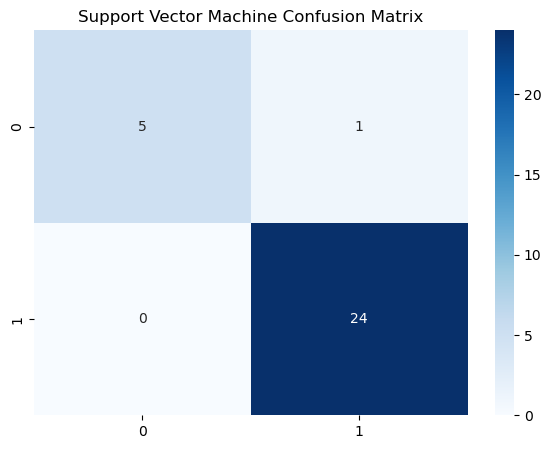

In [31]:
# Confusion Matrix

plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Support Vector Machine Confusion Matrix")
plt.show()

### Model Comparison

In [32]:
# Summary of accuracies
model_accuracies = {
    "Logistic Regression": logreg_accuracy,
    "K-Nearest Neighbors": knn_accuracy,
    "Decision Tree": decision_tree_accuracy,
    "Support Vector Machine": svm_accuracy
}

# Display accuracies
for model, accuracy in model_accuracies.items():
    print(F" {model} Accuracy: {accuracy*100:.2f}%")

 Logistic Regression Accuracy: 93.33%
 K-Nearest Neighbors Accuracy: 80.00%
 Decision Tree Accuracy: 93.33%
 Support Vector Machine Accuracy: 96.67%
